In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\basav\Downloads\layoffs_cleaned.csv")

In [5]:
df.head()

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Included Health,SF Bay Area,Healthcare,NaN,0.06,2022-07-25,Series E,United States,272.0
1,&Open,Dublin,Marketing,9.0,0.09,2022-11-17,Series A,Ireland,35.0
2,#Paid,Toronto,Marketing,19.0,0.17,2023-01-27,Series B,Canada,21.0
3,100 Thieves,Los Angeles,Consumer,12.0,NaN,2022-07-13,Series C,United States,120.0
4,10X Genomics,SF Bay Area,Healthcare,100.0,0.08,2022-08-04,Post-IPO,United States,242.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                1000 non-null   object 
 1   location               1000 non-null   object 
 2   industry               999 non-null    object 
 3   total_laid_off         816 non-null    float64
 4   percentage_laid_off    788 non-null    float64
 5   date                   999 non-null    object 
 6   stage                  998 non-null    object 
 7   country                1000 non-null   object 
 8   funds_raised_millions  911 non-null    float64
dtypes: float64(3), object(6)
memory usage: 70.4+ KB


In [9]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
monthly = df.groupby(pd.Grouper(key='date', freq='M'))['total_laid_off'].sum().reset_index()

monthly.head()

C:\Users\basav\AppData\Local\Temp\ipykernel_98492\3345348721.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key='date', freq='M'))['total_laid_off'].sum().reset_index()


,date,total_laid_off
0,2020-03-31,5100.0
1,2020-04-30,11193.0
2,2020-05-31,10472.0
3,2020-06-30,3073.0
4,2020-07-31,5870.0


In [13]:
monthly.tail()

,date,total_laid_off
32,2022-11-30,26961.0
33,2022-12-31,4839.0
34,2023-01-31,39588.0
35,2023-02-28,23865.0
36,2023-03-31,2347.0


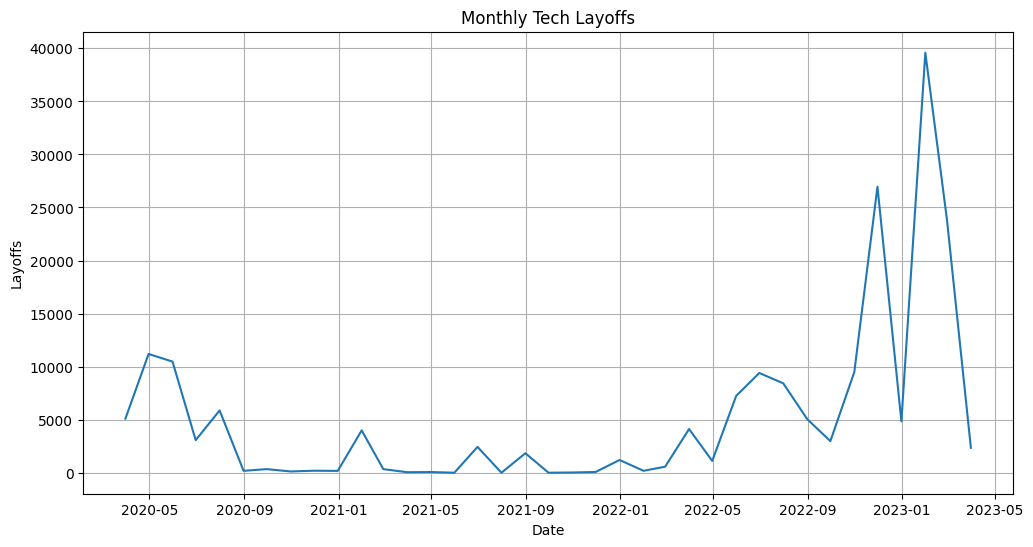

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly['date'], monthly['total_laid_off'])
plt.title('Monthly Tech Layoffs')
plt.xlabel('Date')
plt.ylabel('Layoffs')
plt.grid(True)
plt.show()

In [16]:
!pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------------------ --------------------- 5.5/12.1 MB 30.5 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 31.5 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 26.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [stanio]


In [17]:
forecast_df = monthly.rename(
    columns={
        'date':'ds',
        'total_laid_off':'y'
    }
)

forecast_df.head()

,ds,y
0,2020-03-31,5100.0
1,2020-04-30,11193.0
2,2020-05-31,10472.0
3,2020-06-30,3073.0
4,2020-07-31,5870.0


In [18]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

C:\Users\basav\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
20:59:51 - cmdstanpy - INFO - Chain [1] start processing
20:59:53 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
future = model.make_future_dataframe(periods=12, freq='M')

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(12)

C:\Users\basav\AppData\Local\Programs\Python\Python310\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
37,2023-04-30,1359.118084,-6017.623159,8256.864579
38,2023-05-31,14310.270082,6872.705849,21476.535005
39,2023-06-30,23716.740569,16003.813173,30767.402540
40,2023-07-31,17298.228874,9660.339367,24179.349615
41,2023-08-31,13077.159802,5779.886474,20049.259690
42,2023-09-30,3820.645914,-3393.143502,11132.187932
43,2023-10-31,6598.820302,-477.949429,13370.394486
44,2023-11-30,25125.748443,18017.563014,32336.309147
45,2023-12-31,-5156.085623,-12194.190173,1996.116373
46,2024-01-31,38064.438164,31250.029263,45483.776353


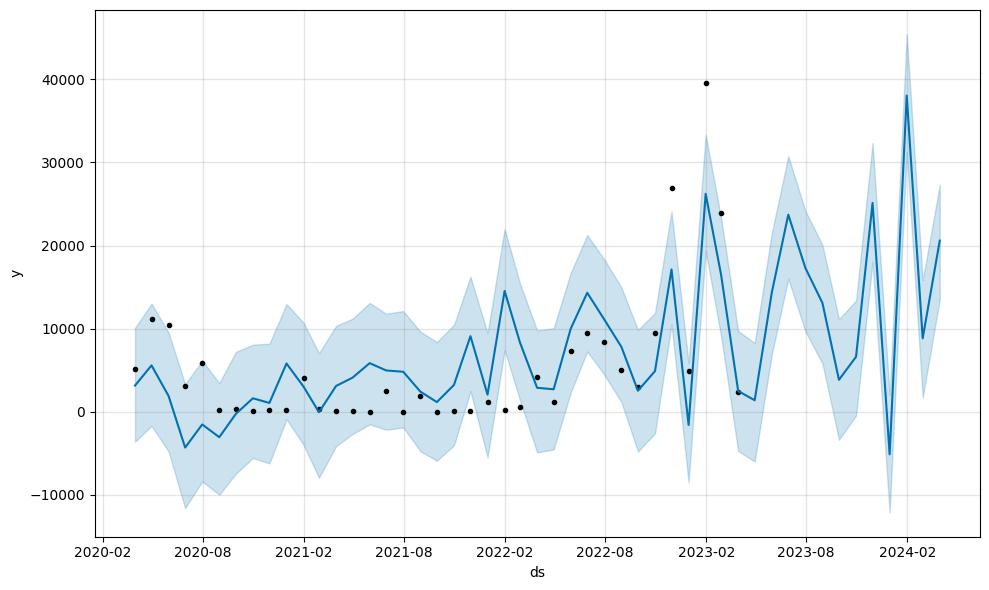

In [20]:
fig = model.plot(forecast)

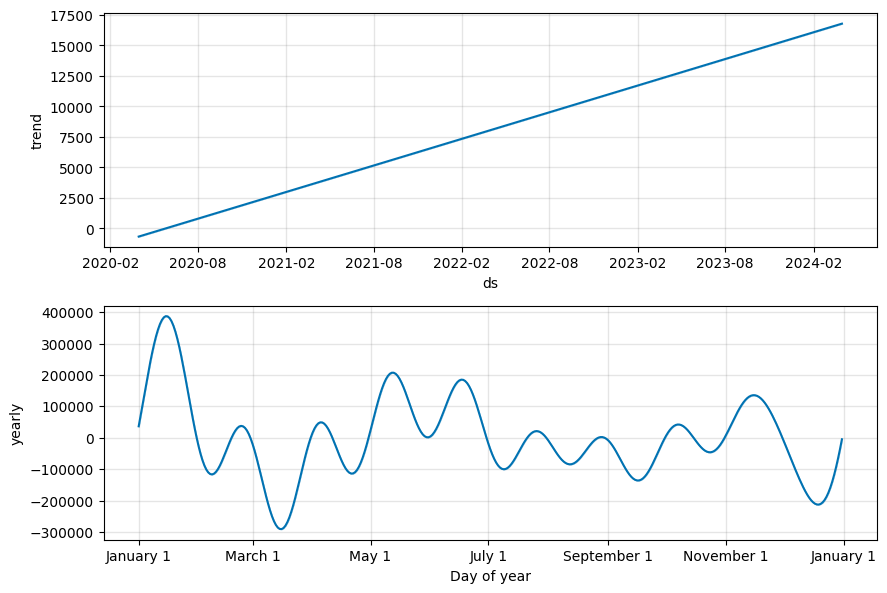

In [21]:
fig2 = model.plot_components(forecast)

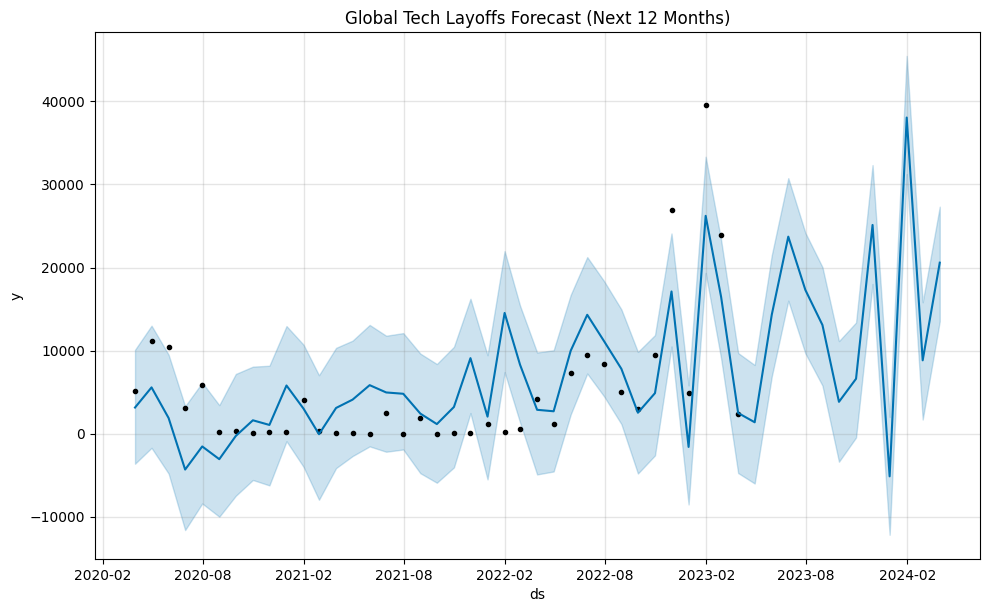

In [24]:
fig = model.plot(forecast)
plt.title("Global Tech Layoffs Forecast (Next 12 Months)")
plt.savefig("layoffs_forecast.png", bbox_inches="tight")
plt.show()

In [25]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    "layoffs_forecast.csv",
    index=False
)